# COVID-19 in Newfoundland and Labrador

This [Jupyter Lab](https://jupyter.org/) notebook analyzes a data set on COVID-19 cases in Canada. The intention is to demonstrate the effectiveness of the [Gompertz function](https://en.wikipedia.org/wiki/Gompertz_function) in describing and predicting the total number of COVID-19 cases, specifically in Newfoundland and Labrador.

## Introduction

The **Gompertz function** is defined by Wikipedia as, "a sigmoid function which describes growth as being slowest at the start and end of a given time period." It is commonly used in modelling many forms of biological growth, including the growth of animals and plants in size, the growth of tumour cells in the body and so on. Can the Gompertz function also describe and predict the growth of COVID-19?

To answer this question, we will create a model centered around the Gompertz function, using it to fit a curve to a record of the total number of COVID-19 cases in the province. From evaluating the accuracy of the results, we should be able to get a good impression of the effectiveness of the Gompertz function in modelling the growth of the pandemic.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
import datetime
import numpy as np
import math
from scipy.optimize import curve_fit

data = pd.read_csv("https://health-infobase.canada.ca/src/data/covidLive/covid19-download.csv")
# Convert totalcases to a number, eliminating any NA results created in the process.
data['totalcases'] = pd.to_numeric(data['totalcases'],errors="coerce")
data = data.dropna(subset='totalcases')
# Convert date from a string into a proper datetime.
data['date'] = pd.to_datetime(data['date'])
# Narrow the data set down to fields relevant to Newfoundland and Labrador.
data = data[data['prname'] == "Newfoundland and Labrador"]
# To avoid instances of division by zero, we'll only consider case numbers
# greater than zero.
data = data[data['totalcases'] != 0]

Now that the basic data tidying is complete, it's possible to proceed with defining the Gompertz function itself. A **training** and **test** data set will also be created by partitioning the original data set; 80% of the records will be used for training the model and the remaining 20% will be used to test its effectiveness.

In [2]:
# Define the Gompertz function.
def gompertz(x, A, B, C):
    return A * np.exp(-B * np.exp(-C * x))

# Split the data into two groups, 80% of which will be used for training the
# model and 20% of which will be used for testing its effectiveness.
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

# Split into X and y for both training and testing sets
X_train = train_data.drop('totalcases', axis=1)
y_train = train_data['totalcases']
X_test = test_data.drop('totalcases', axis=1)
y_test = test_data['totalcases']

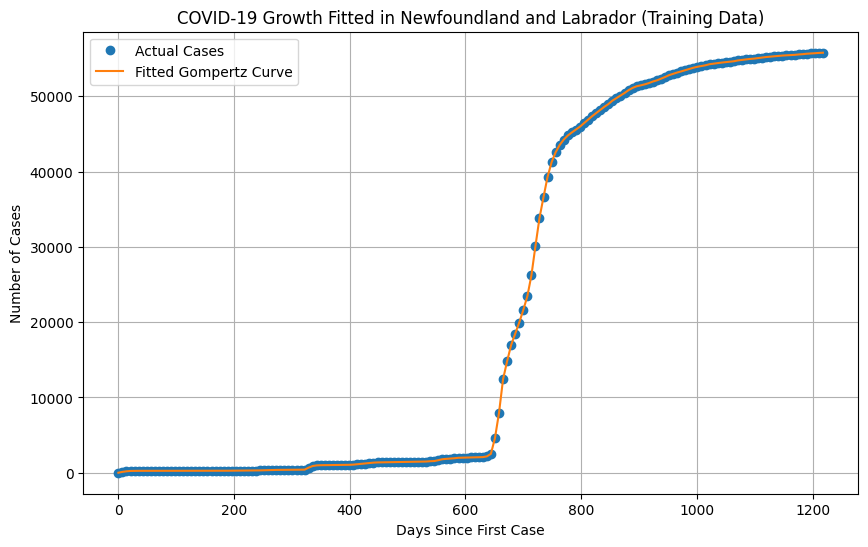

In [3]:
X_train['days'] = (X_train['date'] - X_train['date'].min()).dt.days

# These are the initial guesses for the parameters A, B and C in our function.
initial_guess = [y_train.max(), 1, 0.01]

# Fit the Gompertz curve to the training data set.
params, covariance = curve_fit(gompertz, X_train['days'], y_train, p0=initial_guess)

# Extract the fitted parameters.
A_fit, B_fit, C_fit = params

# Generate fitted values based on the optimized parameters.
X_train['fitted_cases'] = gompertz(X_train['days'], *params)

# Plot the actual data and the fitted curve.

plt.figure(figsize=(10, 6))
plt.plot(X_train['days'], y_train, 'o', label='Actual Cases',color='tab:blue',)  
plt.plot(X_train['days'], y_train, '-', label='Fitted Gompertz Curve',color='tab:orange')
plt.title("COVID-19 Growth Fitted in Newfoundland and Labrador (Training Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)
plt.show()


The model has been trained using a subset of the original data set. We can now evaluate its performance against the test data set.

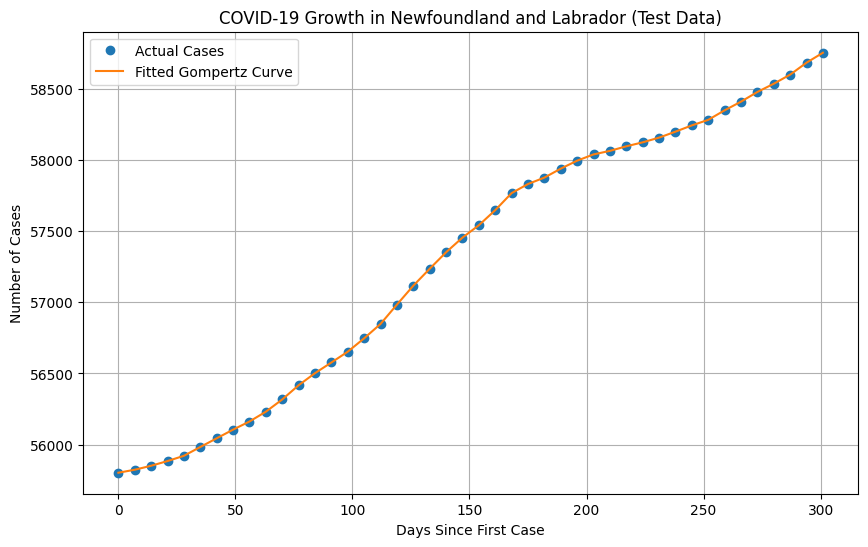

In [4]:
X_test['days'] = (X_test['date'] - X_test['date'].min()).dt.days

initial_guess = [y_test.max(), 1, 0.01]

params, covariance = curve_fit(gompertz, X_test['days'], y_test, p0=initial_guess)

A_fit, B_fit, C_fit = params

X_test['fitted_cases'] = gompertz(X_test['days'], *params)
plt.figure(figsize=(10, 6))
plt.plot(X_test['days'], y_test, 'o', label='Actual Cases',color='tab:blue',)
plt.plot(X_test['days'], y_test, '-', label='Fitted Gompertz Curve',color='tab:orange',)
plt.title("COVID-19 Growth in Newfoundland and Labrador (Test Data)")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)
plt.show()


The model appears to perform reasonably well against the test data set as well. We are now ready to apply the model to the entirety of the data set.

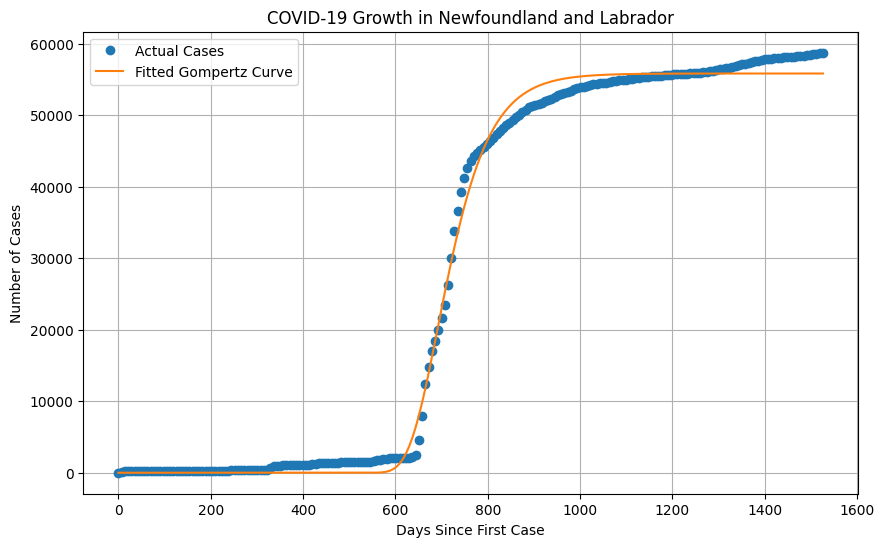

In [13]:
data['days'] = (data['date'] - data['date'].min()).dt.days

initial_guess = [data['totalcases'].max(),1, 0.01]

params, covariance = curve_fit(gompertz, data['days'], data['totalcases'], p0=initial_guess)

A_fit, B_fit, C_fit = params

data['fitted_cases'] = gompertz(data['days'], *params)

plt.figure(figsize=(10, 6))
plt.plot(data['days'], data['totalcases'], 'o', label='Actual Cases',color="tab:blue")
plt.plot(data['days'], data['fitted_cases'], '-', label='Fitted Gompertz Curve',color="tab:orange") 
plt.title("COVID-19 Growth in Newfoundland and Labrador")
plt.xlabel("Days Since First Case")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)
plt.show()


## Conclusion

**No** model is 100% accurate, as we can plainly see. Nonetheless, in terms of modelling the growth of COVID-19 in Newfoundland and Labrador, the Gompertz function provides an excellent model upon which total case numbers can be explained and predicted. This is an incredible result, considering that the disease was not known until a full two centuries after the death of [Benjamin Gompertz,](https://en.wikipedia.org/wiki/Benjamin_Gompertz) in 1865. 

It remains to be seen what the final financial impact of COVID-19 will be. In the case of Newfoundland and Labrador, we can see that it took nearly **1600 days** before case numbers began to level off. During that time, strict quarantine measures were enforced in the province, the effects of which were felt by a myriad of local businesses that were forced to shut down. In such an uncertain environment and with difficulty finding the labour to fill positions, many such businesses were forced to close their doors, not knowing if or when the pandemic would ever truly end.

The Gompertz function **could** potentially provide an answer to policy makers who are attempting to draft and enforce such regulations, as well as to the public, perhaps eliminating some of the uncertainty of operating in a world afflicted by COVID-19. With an accurate means of modelling the growth of the disease, it may be possible to predict its future spread.